# SafeCityAI — Model Training Notebook

This notebook documents the training process for the SafeCityAI helmet and 
license plate detection model, built on YOLOv5, fine-tuned from COCO-pretrained weights.
    

In [2]:
# Clone YOLOv5 (already done locally, shown here for reproducibility)
# !git clone https://github.com/ultralytics/yolov5
# %cd yolov5
# !pip install -r requirements.txt

## Dataset
- 3 classes: `head`, `helmet`, `License_Plate`
- ~2,000+ head/helmet images + ~450 license plate images, merged into one unified dataset
- Verified annotation quality using custom box-size analysis before training (caught and replaced an initial dataset with overly loose bounding boxes)

In [3]:
# Training command used
training_command = """
python train.py --img 640 --batch 16 --epochs 100 \\
    --data ../data/merged_dataset/data.yaml \\
    --weights yolov5s.pt --name safecity_full
"""
print(training_command)


python train.py --img 640 --batch 16 --epochs 100 \
    --data ../data/merged_dataset/data.yaml \
    --weights yolov5s.pt --name safecity_full



## Results
- **mAP@0.5:** 97.3%
- **Precision:** 93.2%
- **Recall:** 94.0%

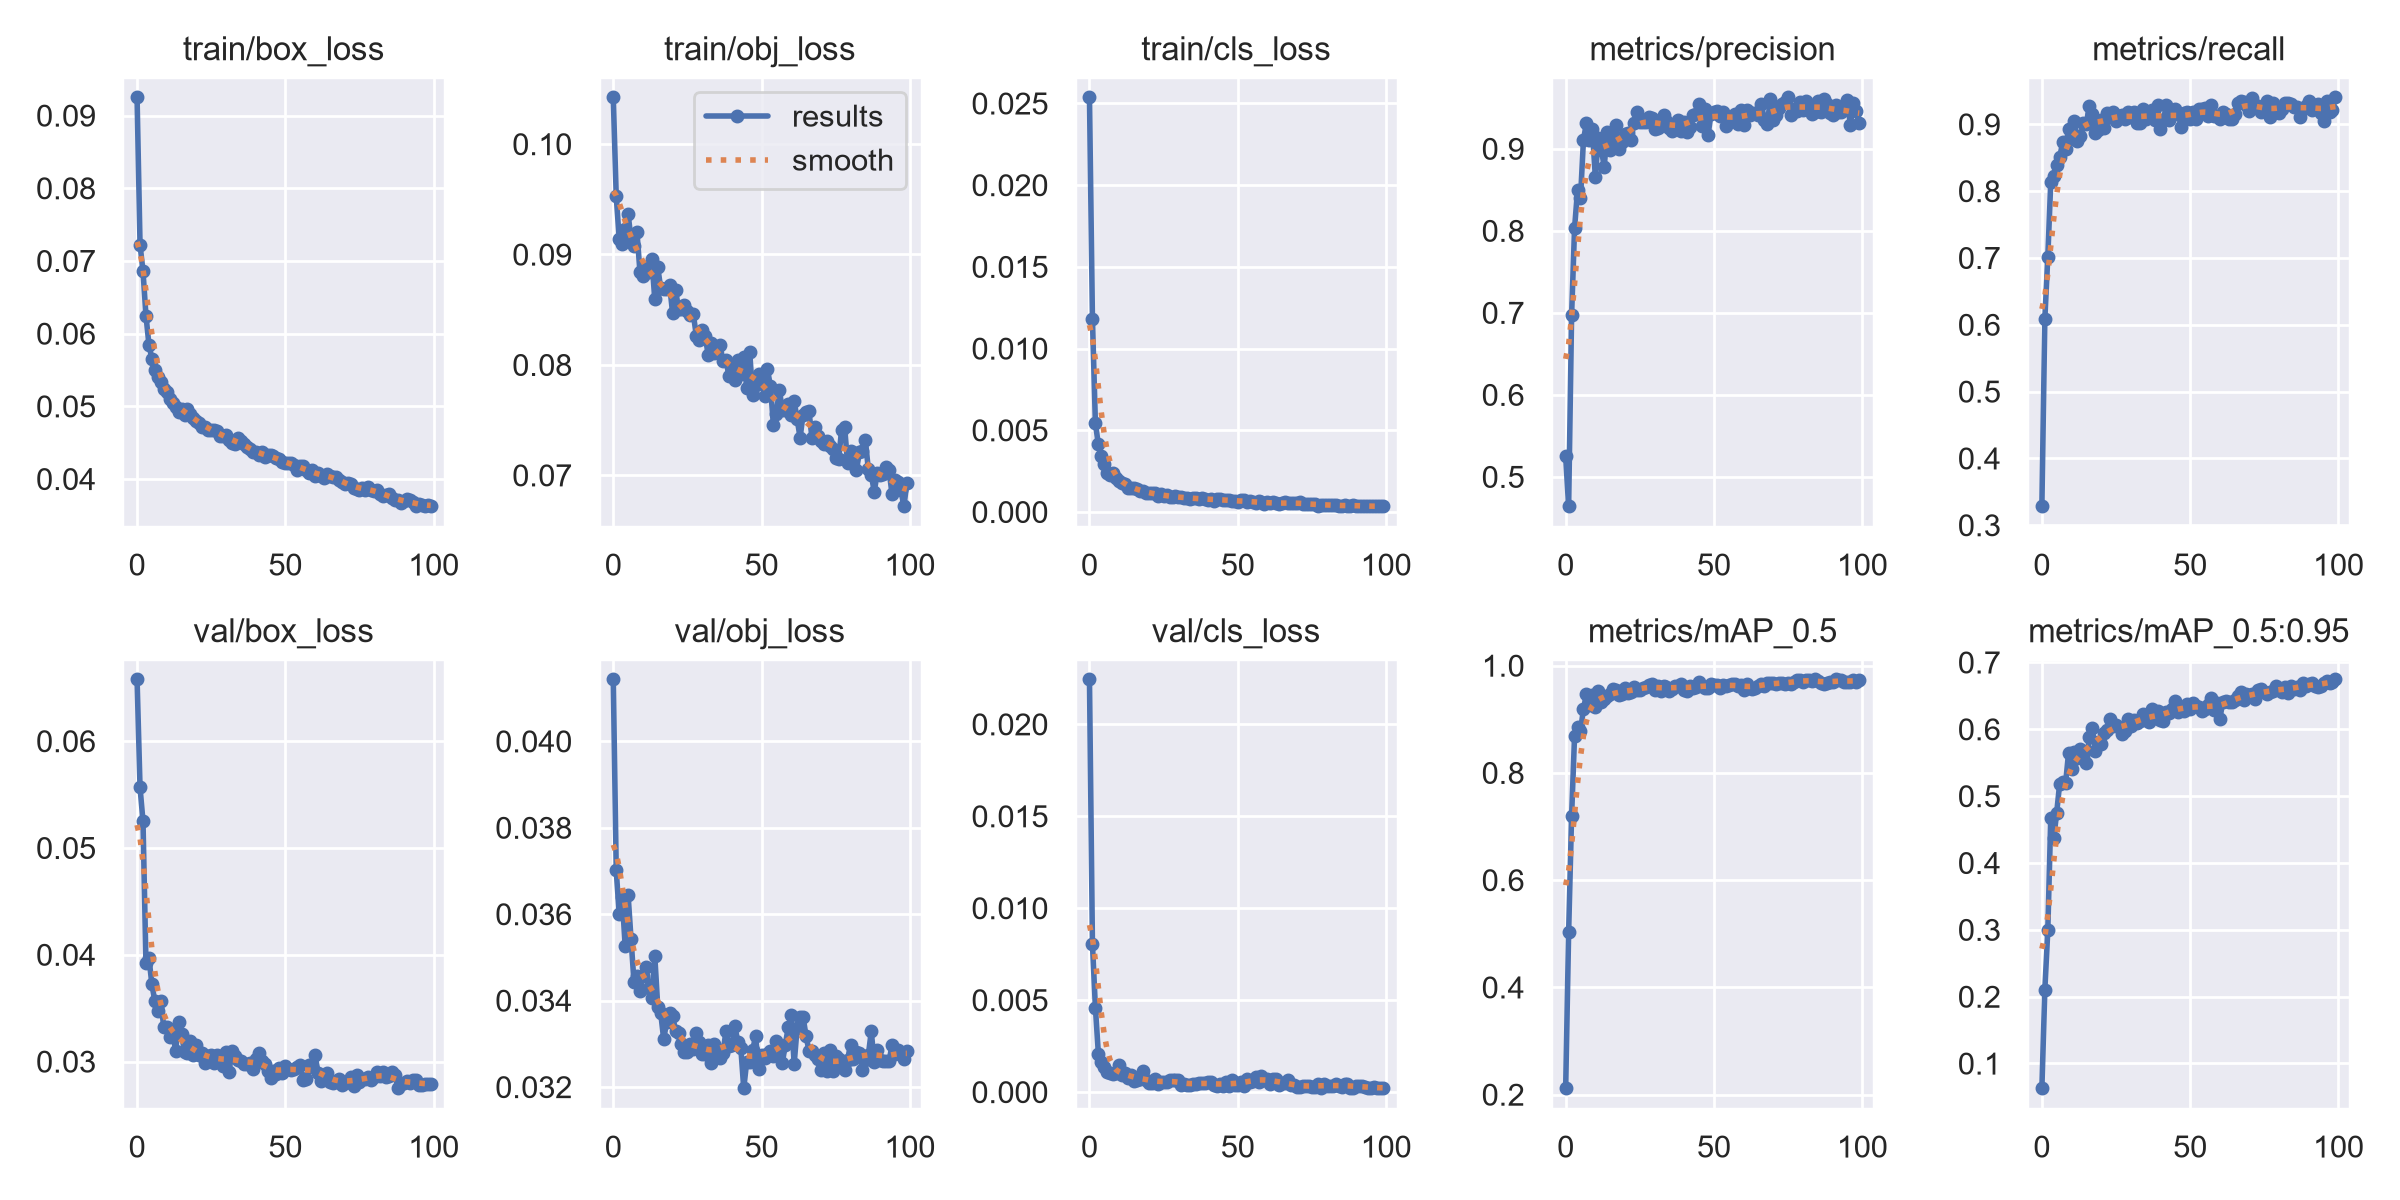

In [4]:
from IPython.display import Image
Image(filename="yolov5/runs/train/safecity_full/results.png")

In [5]:
import pandas as pd
df = pd.read_csv("yolov5/runs/train/safecity_full/results.csv")
df.columns = df.columns.str.strip()
df.tail(10)

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
90,90,0.036964,0.070060,0.000378,0.94130,0.93436,0.96995,0.66793,0.028000,0.032632,0.000309,0.001189,0.001189,0.001189
91,91,0.037244,0.070080,0.000393,0.95282,0.92182,0.97407,0.66843,0.028163,0.032602,0.000354,0.001090,0.001090,0.001090
92,92,0.037049,0.070732,0.000370,0.94426,0.92826,0.97316,0.66513,0.027963,0.032610,0.000320,0.000991,0.000991,0.000991
93,93,0.036764,0.070475,0.000357,0.94477,0.93007,0.97224,0.66320,0.028278,0.032603,0.000299,0.000892,0.000892,0.000892
94,94,0.036286,0.068284,0.000336,0.95010,0.91658,0.97021,0.66440,0.028292,0.032965,0.000209,0.000793,0.000793,0.000793
95,95,0.036521,0.069588,0.000346,0.95914,0.90552,0.96915,0.66851,0.027830,0.032759,0.000217,0.000694,0.000694,0.000694
96,96,0.036469,0.069426,0.000364,0.92871,0.93430,0.97015,0.67240,0.027832,0.032862,0.000282,0.000595,0.000595,0.000595
97,97,0.036214,0.068664,0.000357,0.95632,0.91901,0.97314,0.66888,0.027875,0.032798,0.000193,0.000496,0.000496,0.000496
98,98,0.036449,0.067174,0.000334,0.94661,0.92204,0.97017,0.67086,0.027891,0.032644,0.000216,0.000397,0.000397,0.000397
99,99,0.036220,0.069321,0.000333,0.93181,0.94022,0.97297,0.67457,0.027855,0.032842,0.000241,0.000298,0.000298,0.000298
